1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")


# Load merged dataset
file_path = r"c:\Users\kamru\Documents\AU\Monsoon project\outputs\enso_ghcn_monthly_2000_2025.csv"

df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Year,Month,Nino34,Rainfall_Monthly,TMAX_Monthly,TMIN_Monthly
0,2000,1,24.78,18.3,4.741176,0.662500
1,2000,2,25.21,9.4,2.868421,-1.529412
2,2000,3,26.30,58.7,8.558824,1.800000
3,2000,4,26.95,38.9,10.941176,3.800000
4,2000,5,27.07,17.8,17.612500,9.635294


2. Basic Dataset Information

In [9]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)


print("\nColumns")
print("="*60)

print(df.columns.tolist())


print("\nData Types")
print("="*60)

print(df.dtypes)

Dataset Shape
(312, 6)

Columns
['Year', 'Month', 'Nino34', 'Rainfall_Monthly', 'TMAX_Monthly', 'TMIN_Monthly']

Data Types
Year                  int64
Month                 int64
Nino34              float64
Rainfall_Monthly    float64
TMAX_Monthly        float64
TMIN_Monthly        float64
dtype: object


3. Statistical Summary

In [10]:
df.describe()
# for climate data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,312.0,2012.500000,7.512048,2000.000000,2006.000000,2012.500000,2019.000000,2025.000000
Month,312.0,6.500000,3.457598,1.000000,3.750000,6.500000,9.250000,12.000000
Nino34,312.0,27.008045,0.962023,24.780000,26.257500,27.095000,27.682500,29.420000
Rainfall_Monthly,312.0,42.545833,34.469092,0.000000,17.525000,34.600000,56.700000,242.100000
TMAX_Monthly,312.0,15.373535,8.552741,-0.135294,7.640441,15.395833,21.706250,31.841667
TMIN_Monthly,312.0,8.390253,7.585437,-8.036364,1.362500,7.404902,14.371875,24.158333


4. Missing Value Analysis

In [11]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df)
) * 100


missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})


missing_table

,Missing Values,Percentage
Year,0,0.0
Month,0,0.0
Nino34,0,0.0
Rainfall_Monthly,0,0.0
TMAX_Monthly,0,0.0
TMIN_Monthly,0,0.0


5. Duplicate Check

In [12]:
duplicates = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicates
)

Duplicate rows: 0


6. Date Feature Creation

For time-series analysis:

In [13]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
    + "-01"
)


df.head()

,Year,Month,Nino34,Rainfall_Monthly,TMAX_Monthly,TMIN_Monthly,Date
0,2000,1,24.78,18.3,4.741176,0.662500,2000-01-01
1,2000,2,25.21,9.4,2.868421,-1.529412,2000-02-01
2,2000,3,26.30,58.7,8.558824,1.800000,2000-03-01
3,2000,4,26.95,38.9,10.941176,3.800000,2000-04-01
4,2000,5,27.07,17.8,17.612500,9.635294,2000-05-01


7. Time Coverage Check

In [14]:
print(
    "Start date:",
    df["Date"].min()
)


print(
    "End date:",
    df["Date"].max()
)

Start date: 2000-01-01 00:00:00
End date: 2025-12-01 00:00:00


8. Monthly Rainfall Trend

Target variable analysis.

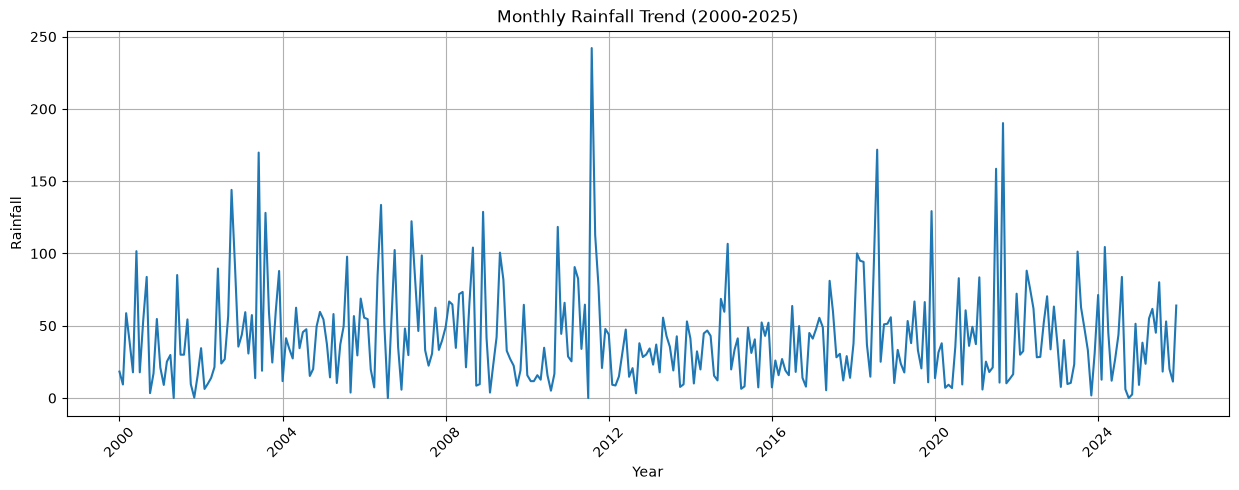

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["Rainfall_Monthly"]
)

plt.title(
    "Monthly Rainfall Trend (2000-2025)"
)

plt.xlabel("Year")

plt.ylabel(
    "Rainfall"
)

plt.xticks(rotation=45)

plt.grid()

plt.show()

9. ENSO Trend

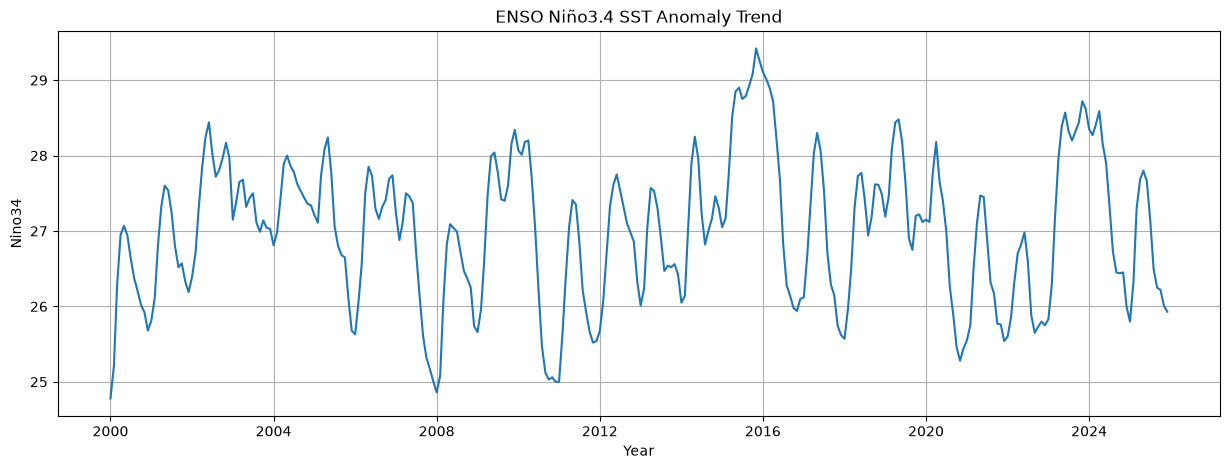

In [16]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["Nino34"]
)


plt.title(
    "ENSO Niño3.4 SST Anomaly Trend"
)

plt.xlabel("Year")

plt.ylabel(
    "Nino34"
)

plt.grid()

plt.show()

10. Temperature Trend

Maximum Temperature

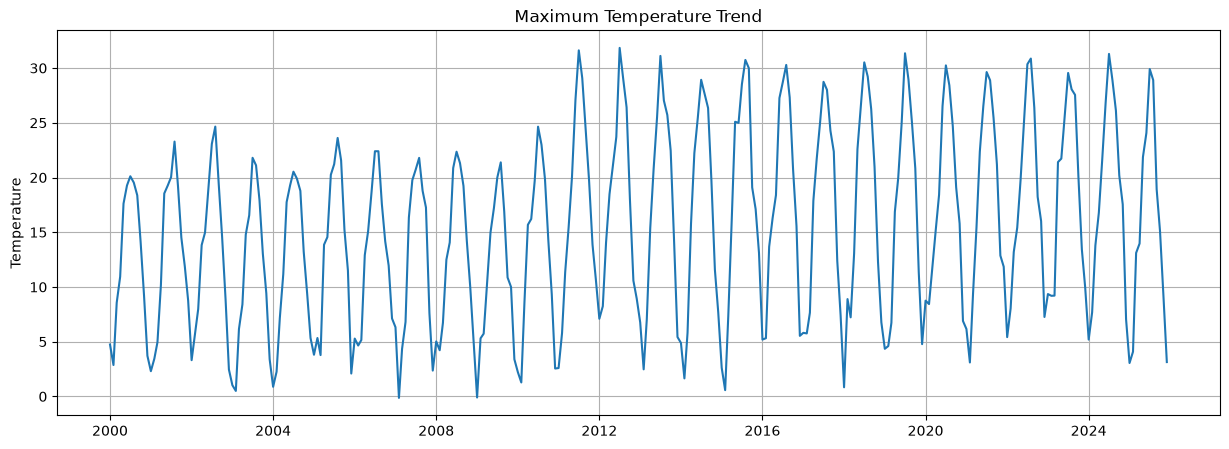

In [17]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["TMAX_Monthly"]
)


plt.title(
    "Maximum Temperature Trend"
)

plt.ylabel(
    "Temperature"
)

plt.grid()

plt.show()

Minimum Temperature

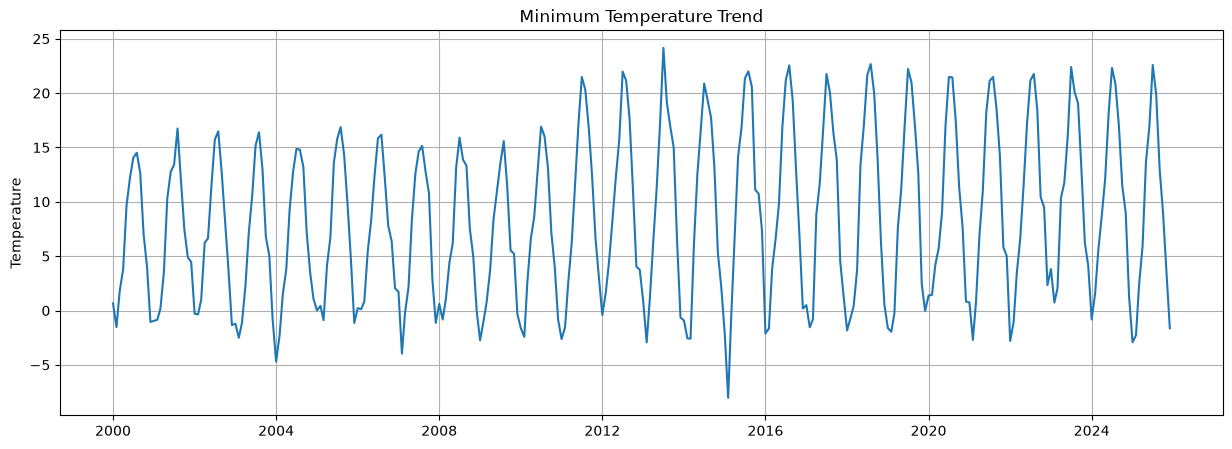

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["TMIN_Monthly"]
)


plt.title(
    "Minimum Temperature Trend"
)

plt.ylabel(
    "Temperature"
)

plt.grid()

plt.show()

11. Monthly Seasonal Pattern

Very important for monsoon prediction.

Average rainfall by month

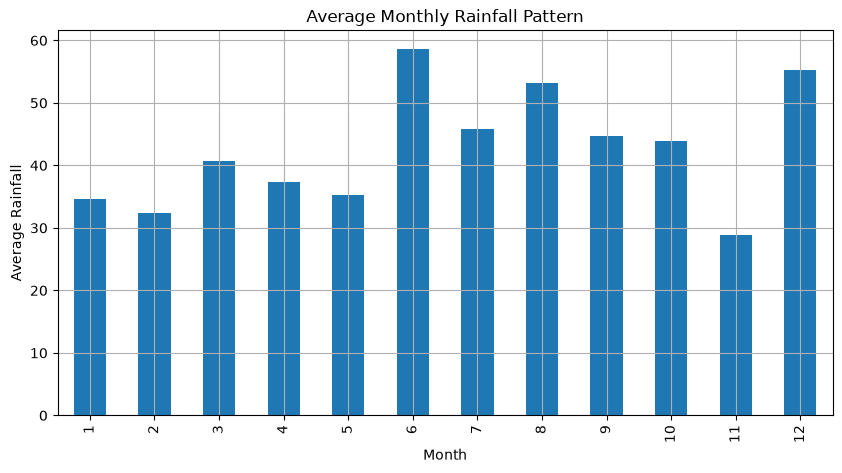

In [19]:
monthly_rainfall = (
    df.groupby("Month")
    ["Rainfall_Monthly"]
    .mean()
)


plt.figure(figsize=(10,5))

monthly_rainfall.plot(
    kind="bar"
)


plt.title(
    "Average Monthly Rainfall Pattern"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Average Rainfall"
)

plt.grid()

plt.show()

12. Temperature Seasonality

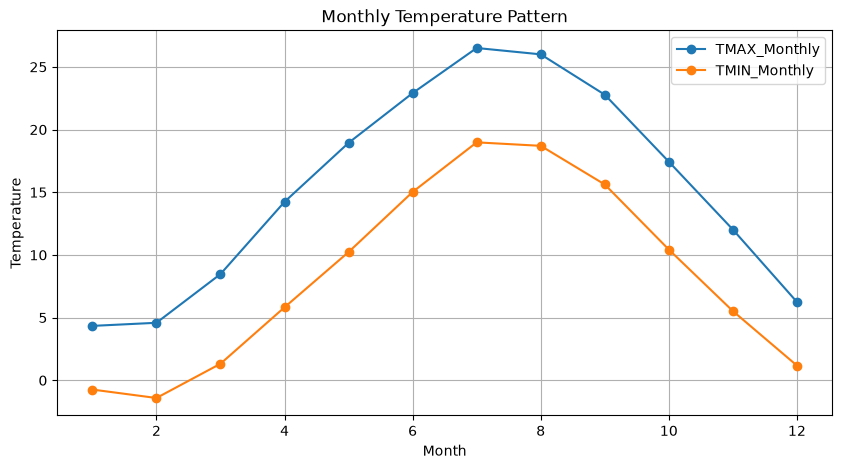

In [20]:
monthly_temp = (
    df.groupby("Month")
    [["TMAX_Monthly",
      "TMIN_Monthly"]]
    .mean()
)


monthly_temp.plot(
    figsize=(10,5),
    marker="o"
)


plt.title(
    "Monthly Temperature Pattern"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Temperature"
)

plt.grid()

plt.show()

13. Correlation Analysis


In [21]:
corr = df[
    [
        "Nino34",
        "Rainfall_Monthly",
        "TMAX_Monthly",
        "TMIN_Monthly"
    ]
].corr()


corr

,Nino34,Rainfall_Monthly,TMAX_Monthly,TMIN_Monthly
Nino34,1.000000,-0.032168,0.243550,0.203572
Rainfall_Monthly,-0.032168,1.000000,0.070199,0.106557
TMAX_Monthly,0.243550,0.070199,1.000000,0.984047
TMIN_Monthly,0.203572,0.106557,0.984047,1.000000


Correlation Heatmap

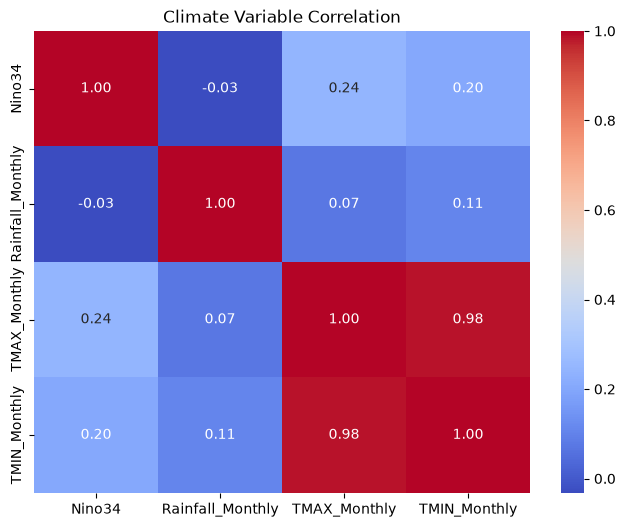

In [22]:
plt.figure(figsize=(8,6))


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)


plt.title(
    "Climate Variable Correlation"
)


plt.show()

14. Feature vs Target Relationship

ENSO vs Rainfall

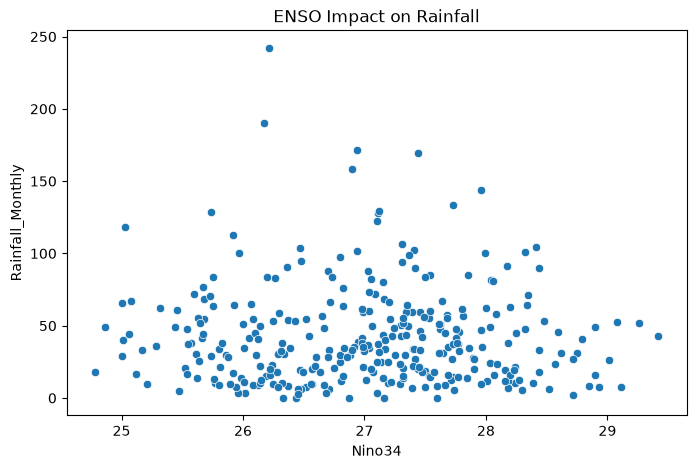

In [23]:
plt.figure(figsize=(8,5))


sns.scatterplot(
    data=df,
    x="Nino34",
    y="Rainfall_Monthly"
)


plt.title(
    "ENSO Impact on Rainfall"
)


plt.show()

Temperature vs Rainfall

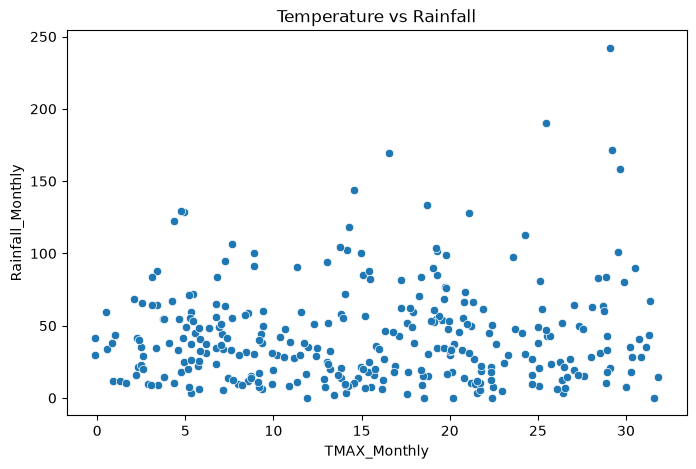

In [24]:
plt.figure(figsize=(8,5))


sns.scatterplot(
    data=df,
    x="TMAX_Monthly",
    y="Rainfall_Monthly"
)


plt.title(
    "Temperature vs Rainfall"
)


plt.show()

15. Rainfall Distribution

Check skewness.

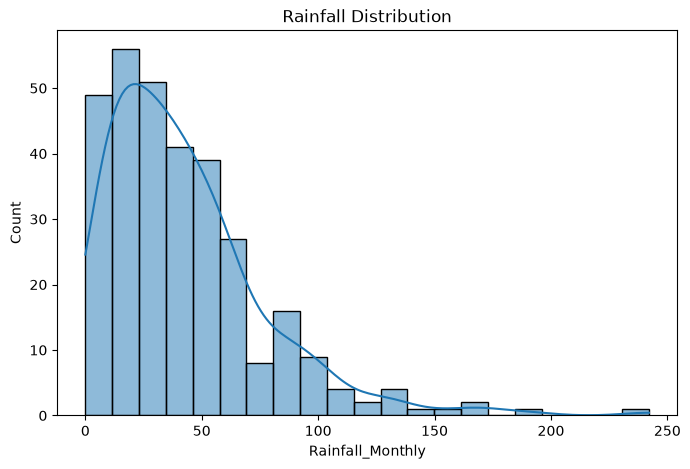

In [25]:
plt.figure(figsize=(8,5))


sns.histplot(
    df["Rainfall_Monthly"],
    kde=True
)


plt.title(
    "Rainfall Distribution"
)


plt.show()

16. Boxplots for Outliers

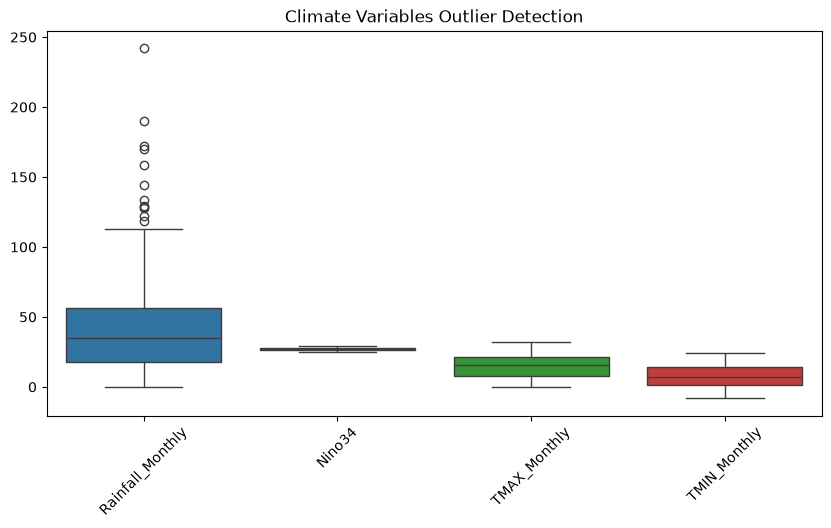

In [26]:
plt.figure(figsize=(10,5))


sns.boxplot(
    data=df[
        [
            "Rainfall_Monthly",
            "Nino34",
            "TMAX_Monthly",
            "TMIN_Monthly"
        ]
    ]
)


plt.title(
    "Climate Variables Outlier Detection"
)


plt.xticks(rotation=45)


plt.show()

17. Lag Analysis 

ENSO usually affects rainfall after some months.

Create lag features:

In [27]:
for lag in [1,3,6,12]:

    df[f"Nino34_lag_{lag}"] = (
        df["Nino34"]
        .shift(lag)
    )


df.head(15)

,Year,Month,Nino34,Rainfall_Monthly,TMAX_Monthly,TMIN_Monthly,Date,Nino34_lag_1,Nino34_lag_3,Nino34_lag_6,Nino34_lag_12
0,2000,1,24.78,18.3,4.741176,0.662500,2000-01-01,NaN,NaN,NaN,NaN
1,2000,2,25.21,9.4,2.868421,-1.529412,2000-02-01,24.78,NaN,NaN,NaN
2,2000,3,26.30,58.7,8.558824,1.800000,2000-03-01,25.21,NaN,NaN,NaN
3,2000,4,26.95,38.9,10.941176,3.800000,2000-04-01,26.30,24.78,NaN,NaN
4,2000,5,27.07,17.8,17.612500,9.635294,2000-05-01,26.95,25.21,NaN,NaN
5,2000,6,26.94,101.6,19.268750,12.218750,2000-06-01,27.07,26.30,NaN,NaN
6,2000,7,26.63,17.8,20.112500,14.056250,2000-07-01,26.94,26.95,24.78,NaN
7,2000,8,26.37,53.8,19.537500,14.512500,2000-08-01,26.63,27.07,25.21,NaN
8,2000,9,26.20,83.8,18.375000,12.631250,2000-09-01,26.37,26.94,26.30,NaN
9,2000,10,26.02,3.4,14.143750,7.033333,2000-10-01,26.20,26.63,26.95,NaN


Correlation:

In [28]:
lag_corr = {}

for lag in [1,3,6,12]:

    lag_corr[lag] = (
        df[
            [
                f"Nino34_lag_{lag}",
                "Rainfall_Monthly"
            ]
        ]
        .corr()
        .iloc[0,1]
    )


lag_corr

{1: np.float64(-0.00604660364365215),
 3: np.float64(-0.033331938521439286),
 6: np.float64(-0.1288040799229756),
 12: np.float64(-0.0058937521163628)}

18. Save EDA Dataset

In [30]:
import os

# Create outputs folder if it does not exist
os.makedirs("outputs", exist_ok=True)

# Save EDA dataset
df.to_csv(
    "outputs/eda_ready_enso_ghcn.csv",
    index=False
)

print("File saved successfully!")
print("Location: outputs/eda_ready_enso_ghcn.csv")

File saved successfully!
Location: outputs/eda_ready_enso_ghcn.csv
